# Synthetic publication figure — per-panel adaptable cells

Mirrors [plot_publication_figure_nestedcv.py](plot_publication_figure_nestedcv.py) but split into one self-contained cell per panel. Each plot cell reloads its own data so cells can be edited and re-run independently.

Panels:
- **a** — held-out NLL per session (cog models + IDRNN/Vanilla/CP-RNN)
- **b (RSA)** — dim-matched RSA r between latents and true α
- **b (R²)** — dim-matched LOO ridge α-decoding R²
- **c** — α vs IDRNN canonical z scatter (dataset 0)
- **d** — environment-structure decoding
- **e** — three-regression simulation (R1/R2/R3 → α)

## Setup — palette, fonts, helpers

Run once. No data is loaded here; data loads live in each panel cell.

In [1]:
import os, json, logging
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearsonr
from cycler import cycler
from matplotlib.colors import to_rgb, to_hex
try:
    from pingouin import bayesfactor_ttest, bayesfactor_pearson
except Exception:
    bayesfactor_ttest = bayesfactor_pearson = None

# Nature palette only — we apply Nature *style* manually below so we can
# substitute an installed font for Arial (Arial isn't on this Linux box).
from nature_plot_style import nature_colors

# Belt-and-suspenders: silence matplotlib's font-not-found logger before any
# rendering happens, in case some cached call still asks for Arial.
matplotlib.set_loglevel("error")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
logging.getLogger("matplotlib").setLevel(logging.ERROR)

# Nature style — copy of nature_plot_style.set_nature_style() but with the
# font.family set to a font that actually exists locally (Nimbus Sans is a
# Helvetica clone, visually very close to Arial).
plt.rcParams.update({
    "pdf.fonttype":       42,
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Nimbus Sans", "DejaVu Sans"],
    "font.size":          8,
    "axes.titlesize":     8,
    "axes.titleweight":   "bold",
    "axes.labelsize":     8,
    "xtick.labelsize":    7,
    "ytick.labelsize":    7,
    "legend.fontsize":    7,
    "legend.frameon":     False,
    "axes.linewidth":     1,
    "xtick.major.width":  1,
    "ytick.major.width":  1,
    "xtick.minor.width":  1,
    "ytick.minor.width":  1,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.autolayout":  False,  # we use tight_layout() per cell
    "axes.prop_cycle": cycler("color", [
        "#dd9e9e",
        "#D04C4C",
        "#f59e57",
        "#6f6484",
        "#101e41",
        "#fccc9b",
        "#666666",
    ])
})

def lighten(color, amount=0.5):
    c = np.array(to_rgb(color))
    white = np.array([1,1,1])
    return to_hex(c + (white - c) * amount)

# Map panel colors to the Nature palette.  Shade index: 0=lightest, 5=darkest.
# Light/dark pairings (CP=light, EM=dark) are preserved so panel-a pairs read.
COL_Q_EM       = "#6f64842c"#nature_colors['Grey'][4]        # dark grey-blue  (ill-spec EM)
COL_Q_CP       = lighten(COL_Q_EM, 0.4)#nature_colors['Grey'][2]        # light grey-blue (ill-spec CP)

COL_FQ_CP      = "#dd9e9e"#nature_colors['Green'][1]       # light green     (cog model CP)
COL_FQ_EM      = "#D04C4C"#nature_colors['Green'][3]       # mid-dark green  (cog model EM)
COL_IDRNN      = "#132551" #nature_colors['Blue'][3]        # nature blue     (IDRNN)
COL_RNN_CP     = lighten(COL_IDRNN, 0.2)#nature_colors['Blue'][1]        # light blue      (CP RNN)
COL_IDRNN_H    = nature_colors['Blue'][2]        # mid blue        (IDRNN h)
COL_VANILLA    = "#f59e57"#nature_colors['Orange'][3]      # nature orange   (Vanilla)
COL_VAN_H      = "#fccc9b"#nature_colors['Skin tones'][3]  # warm brown      (Vanilla+h avg)
COL_VAN_H_LAST = nature_colors['Skin tones'][1]  # light brown     (Vanilla+h last)
COL_TRUE       = nature_colors['Grey'][5]        # near-black

def fmt_bf(bf):
    if bf is None or not np.isfinite(bf): return "—"
    return f"{bf:.1e}" if bf>=1000 else (f"{bf:.1f}" if bf>=10 else f"{bf:.2f}")

def paired_bf(a, b):
    a=np.asarray(a,float); b=np.asarray(b,float); m=np.isfinite(a)&np.isfinite(b)
    if bayesfactor_ttest is None or m.sum()<3: return float("nan")
    t=stats.ttest_rel(a[m],b[m]).statistic
    return float(bayesfactor_ttest(t, m.sum(), paired=True))

def bracket(ax, x1, x2, y, h, txt):
    #ax.plot([x1,x1,x2,x2],[y,y+h,y+h,y], lw=0.8, c="black")
    ax.plot([x1, x2], [y+h, y+h], lw=0.5, c="black")
    ax.text((x1+x2)/2, y + h*1.1, txt, ha="center", va="bottom", fontsize=6)

def fold_mean(rec, arch, key):
    vals=[fv[arch][key] for fk,fv in rec['folds'].items() if 'error' not in fv.get(arch,{})]
    return float(np.mean(vals)) if vals else np.nan

# Nature column widths: single = 89 mm ≈ 3.5 in, double = 183 mm ≈ 7.2 in
MM_PER_IN = 25.4
def in_from_mm(mm): return mm / MM_PER_IN
SINGLE_COL_IN = in_from_mm(89)
DOUBLE_COL_IN = in_from_mm(183)

DATASETS = [0, 1, 2, 3, 5, 7, 10, 12, 15, 17]
T_TRIALS = 200
Z1_BASE  = "final_plots/synthetic/nested_cv_z1"
CANON_DS0 = "final_plots/synthetic_z1/dataset0/canonical/idrnn"
print("Setup ready.")

Setup ready.


## Panel a — held-out NLL per session

Cog models (Q/FQ × CP/EM) + RNNs (CP-RNN, IDRNN, Vanilla) on 10 synthetic datasets.

Data sources:
- `data_dataset{D}/model_eval_dfvanilla.csv` — per-session NLL for the cog fits + True-model reference.
- `final_plots/synthetic/nested_cv_z1/dataset{D}/nested_cv_summary.json` — IDRNN/Vanilla per-trial NLL (× 200 → per-session).
- `cp_rnn_nll_nestedcv.csv` — CP-RNN held-out NLL (IDRNN with z=0).

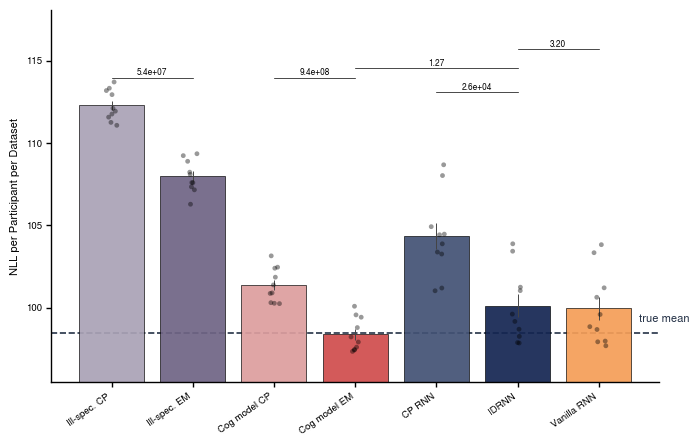

In [2]:
# --- Load panel-a data ---
cog_keys = [("Q_CP","Q (common fit)"),("Q_EM","Q (MAP)"),
            ("FQ_CP","FQ (common fit)"),("FQ_EM","FQ (MAP)"),
            ("True","True model")]
nll_df = {k: [] for k in ["Q_CP","Q_EM","FQ_CP","FQ_EM","RNN_CP","IDRNN","Vanilla","True"]}
cp_df = pd.read_csv("cp_rnn_nll_nestedcv.csv") if os.path.exists("cp_rnn_nll_nestedcv.csv") else None
# Cognitive-model NLLs from the per-fold refit (compute_synthetic_cog_nll_perfold.py):
# fit on each nested-CV fold's train subjects, evaluated on the SAME held-out fold
# subjects as the RNN bars (legacy model_eval_dfvanilla.csv used the separate test
# simulation — a different population draw; kept only as fallback).
cog_pf = (pd.read_csv("cog_nll_perfold_synthetic.csv")
          if os.path.exists("cog_nll_perfold_synthetic.csv") else None)
if cog_pf is None:
    print("WARNING NLL panel: cog_nll_perfold_synthetic.csv missing -> "
          "legacy test-sim cog NLLs (NOT the same eval subjects as the RNNs)")
for D in DATASETS:
    pf = cog_pf[cog_pf["dataset_id"]==D] if cog_pf is not None else None
    if pf is not None and len(pf):
        for tag, name in cog_keys:
            v = pf[pf["model"]==name]["nll_summed"].values
            nll_df[tag].append(float(np.mean(v)) if len(v) else np.nan)
    else:
        if cog_pf is not None:
            print(f"WARNING NLL panel: dataset {D} missing from per-fold CSV -> legacy fallback")
        ev = pd.read_csv(f"data_dataset{D}/model_eval_dfvanilla.csv")
        for tag, name in cog_keys:
            v = ev[ev["model"]==name]["normalized_likelihood"].values
            nll_df[tag].append(float(np.mean(v)) if len(v) else np.nan)
    rec = json.load(open(f"{Z1_BASE}/dataset{D}/nested_cv_summary.json"))
    s = rec["summary"]
    nll_df["IDRNN"].append(s["nll_idrnn_mean"] * T_TRIALS)
    nll_df["Vanilla"].append(s["nll_vanilla_mean"] * T_TRIALS)
    if cp_df is not None:
        nll_df["RNN_CP"].append(float(cp_df[cp_df["dataset_id"]==D]["nll_summed"].mean()))
    else:
        nll_df["RNN_CP"].append(np.nan)
nll_df = pd.DataFrame(nll_df)

bf_Q  = paired_bf(nll_df["Q_CP"],  nll_df["Q_EM"])
bf_FQ = paired_bf(nll_df["FQ_CP"], nll_df["FQ_EM"])
bf_RNNCP_IDRNN = paired_bf(nll_df["RNN_CP"], nll_df["IDRNN"])
bf_Van_IDRNN   = paired_bf(nll_df["Vanilla"], nll_df["IDRNN"])
bf_IDRNN_FQ_EM = paired_bf(nll_df["FQ_EM"], nll_df["IDRNN"])

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["Ill-spec. CP","Ill-spec. EM","Cog model CP","Cog model EM",
          "CP RNN","IDRNN","Vanilla RNN"]
keys   = ["Q_CP","Q_EM","FQ_CP","FQ_EM","RNN_CP","IDRNN","Vanilla"]
cols   = [COL_Q_CP,COL_Q_EM,COL_FQ_CP,COL_FQ_EM,COL_RNN_CP,COL_IDRNN,COL_VANILLA]
means  = [nll_df[k].mean() for k in keys]
sems   = [stats.sem(nll_df[k].dropna()) for k in keys]
xs     = np.arange(len(labels))
ax.bar(xs, means, color=cols, alpha=0.92, edgecolor="black", linewidth=0.5, zorder=2)
ax.errorbar(xs, means, yerr=sems, fmt="none", ecolor="#444444",
            elinewidth=0.7, capsize=0, zorder=3)
rng = np.random.default_rng(0)
for i, k in enumerate(keys):
    v = nll_df[k].dropna().values
    if len(v) == 0: continue
    ax.scatter(xs[i] + rng.normal(0, 0.05, len(v)), v, s=12,
               c="black", alpha=0.4, zorder=4, edgecolors="none")
true_mean = nll_df["True"].mean()
chance = np.log(2)*200
ax.axhline(true_mean, ls="--", color=COL_TRUE, lw=1.2, zorder=1)
#ax.axhline(chance, ls=":", color=COL_TRUE, lw=1.2, zorder=1)
ymax = max(means) + max(sems); h_step = 0.05 * (max(means) - true_mean)
yb = ymax + h_step
bracket(ax, 0, 1, yb,                  h_step*0.3, fmt_bf(bf_Q))
bracket(ax, 2, 3, yb,                  h_step*0.3, fmt_bf(bf_FQ))
bracket(ax, 4, 5, yb-h_step*1.3,                  h_step*0.3, fmt_bf(bf_RNNCP_IDRNN))
bracket(ax, 5, 6, yb + h_step*2.5,     h_step*0.3, fmt_bf(bf_Van_IDRNN))
bracket(ax, 3, 5, yb+ 0.85*h_step,      h_step*0.3, fmt_bf(bf_IDRNN_FQ_EM))
ax.set_xticks(xs); ax.set_xticklabels(labels, rotation=35, ha="right")
ax.set_ylabel("NLL per Participant per Dataset")
ax.set_ylim(bottom=true_mean-3, top=ymax+5)
#ax.text(1.03, chance-2, "chance", color=COL_TRUE,
#        va="bottom", ha="right",
#        transform=ax.get_yaxis_transform(), fontsize=8)
ax.text(1.05, true_mean+0.5, "true mean", color=COL_TRUE,
        va="bottom", ha="right",
        transform=ax.get_yaxis_transform(), fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
#ax.set_title("a", loc="left", fontweight="bold")
plt.tight_layout()
plt.savefig("final_plots/synthetic_nll.png", dpi=600, bbox_inches="tight")
plt.show()

## Panel b (RSA) — dim-matched RSA r vs true α

Loads the same per-dataset nested-CV summary files and pulls `rsa_r_mean_across_seeds` for IDRNN / Vanilla.

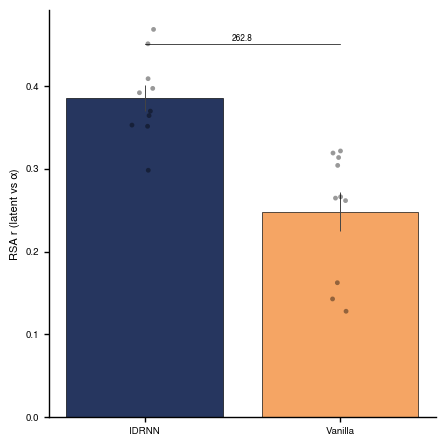

In [3]:
# --- Load panel-b (RSA) data ---
rsa_idr, rsa_van = [], []
for D in DATASETS:
    rec = json.load(open(f"{Z1_BASE}/dataset{D}/nested_cv_summary.json"))
    rsa_idr.append(fold_mean(rec, "idrnn",   "rsa_r_mean_across_seeds"))
    rsa_van.append(fold_mean(rec, "vanilla", "rsa_r_mean_across_seeds"))
rsa_idr = np.array(rsa_idr); rsa_van = np.array(rsa_van)
bf_rsa = paired_bf(rsa_idr, rsa_van)

# --- Plot ---
fig, ax = plt.subplots(figsize=(4.5, 4.5))
di, dv, bf, ylab = rsa_idr, rsa_van, bf_rsa, "RSA r (latent vs α)"
xs=[0,1]; means=[np.nanmean(di), np.nanmean(dv)]
sems=[stats.sem(di[np.isfinite(di)]), stats.sem(dv[np.isfinite(dv)])]
ax.bar(xs, means, color=[COL_IDRNN, COL_VANILLA],
       edgecolor="black", linewidth=0.5, alpha=0.92, zorder=2)
ax.errorbar(xs, means, yerr=sems, fmt="none", ecolor="#444444",
            elinewidth=0.7, capsize=0, zorder=3)
rng = np.random.default_rng(1)
for i,d in enumerate([di, dv]):
    ax.scatter(xs[i] + rng.normal(0, 0.05, len(d)), d, s=12,
               c="black", alpha=0.4, edgecolors="none", zorder=4)
ax.set_xticks(xs); ax.set_xticklabels(["IDRNN","Vanilla"])
ax.set_ylabel(ylab); ax.axhline(0, color="grey", lw=0.5)
ymax = max(means) + max(sems)
bracket(ax, 0, 1, ymax*1.05, ymax*0.05, fmt_bf(bf))
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
#ax.set_title("b (RSA)", loc="left", fontweight="bold")
plt.tight_layout()
plt.savefig("final_plots/synthetic_rsa.png", dpi=600, bbox_inches="tight")
plt.show()

## Panel b (R²) — dim-matched LOO ridge α-decoding

Same data files as RSA, but pulls `decode_r2_mean_across_seeds` instead.

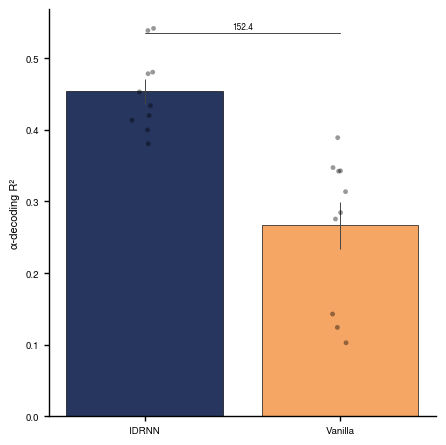

In [4]:
# --- Load panel-b (R²) data ---
r2_idr, r2_van = [], []
for D in DATASETS:
    rec = json.load(open(f"{Z1_BASE}/dataset{D}/nested_cv_summary.json"))
    r2_idr.append(fold_mean(rec, "idrnn",   "decode_r2_mean_across_seeds"))
    r2_van.append(fold_mean(rec, "vanilla", "decode_r2_mean_across_seeds"))
r2_idr = np.array(r2_idr); r2_van = np.array(r2_van)
bf_r2 = paired_bf(r2_idr, r2_van)

# --- Plot ---
fig, ax = plt.subplots(figsize=(4.5, 4.5))
di, dv, bf, ylab = r2_idr, r2_van, bf_r2, "α-decoding R²" #it's LOO ridge
xs=[0,1]; means=[np.nanmean(di), np.nanmean(dv)]
sems=[stats.sem(di[np.isfinite(di)]), stats.sem(dv[np.isfinite(dv)])]
ax.bar(xs, means, color=[COL_IDRNN, COL_VANILLA],
       edgecolor="black", linewidth=0.5, alpha=0.92, zorder=2)
ax.errorbar(xs, means, yerr=sems, fmt="none", ecolor="#444444",
            elinewidth=0.7, capsize=0, zorder=3)
rng = np.random.default_rng(1)
for i,d in enumerate([di, dv]):
    ax.scatter(xs[i] + rng.normal(0, 0.05, len(d)), d, s=12,
               c="black", alpha=0.4, edgecolors="none", zorder=4)
ax.set_xticks(xs); ax.set_xticklabels(["IDRNN","Vanilla"])
ax.set_ylabel(ylab); ax.axhline(0, color="grey", lw=0.5)
ymax = max(means) + max(sems)
bracket(ax, 0, 1, ymax*1.05, ymax*0.05, fmt_bf(bf))
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
#ax.set_title("b (R²)", loc="left", fontweight="bold")
plt.tight_layout()
plt.savefig("final_plots/synthetic_loo.png", dpi=600, bbox_inches="tight")
plt.show()

## Panel c — α vs IDRNN canonical z (dataset 0)

Data sources:
- `final_plots/synthetic_z1/dataset0/canonical/idrnn/latents_train.npy` — canonical IDRNN latents (z_dim=1 so PC1 = z).
- `data_dataset0/true_parameter_values.csv` — ground-truth learning rates.

/tmp/ipykernel_3123949/3299971988.py:26: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Nimbus Sans.
  plt.tight_layout()
/tmp/ipykernel_3123949/3299971988.py:26: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Nimbus Sans.
  plt.tight_layout()
/tmp/ipykernel_3123949/3299971988.py:27: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Nimbus Sans.
  plt.savefig("final_plots/synthetic_scatter.png", dpi=600, bbox_inches="tight")
/tmp/ipykernel_3123949/3299971988.py:27: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Nimbus Sans.
  plt.savefig("final_plots/synthetic_scatter.png", dpi=600, bbox_inches="tight")
/ictstr01/home/hcai/marvin.mathony/tools/apps/mamba/envs/RNNproject/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Nimbus Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/ictstr01/home/hcai/marvin.mathony/tools/apps/mamba/envs/RNNproject/li

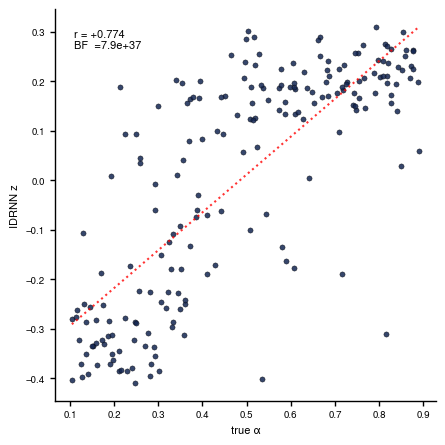

In [5]:
# --- Load panel-c data ---
# latents_train.npy is shape (n_subj, z_dim).  With z_dim=1 it's raw 1-D
# IDRNN z — no PCA involved; PC1 only matters for z_dim>1.
z0 = np.load(f"{CANON_DS0}/latents_train.npy").reshape(-1)
alpha0 = pd.read_csv("data_dataset0/true_parameter_values.csv")["alphaP_list"].values[:len(z0)]
r_c = float(np.corrcoef(alpha0, z0)[0,1])
bf_c = float(bayesfactor_pearson(r_c, len(z0))) if bayesfactor_pearson else float("nan")
# Sign of z is arbitrary — flip so correlation is positive
if r_c < 0:
    z0 = -z0; r_c = -r_c

# Fit regression line
slope, intercept = np.polyfit(alpha0, z0, 1)
x_line = np.linspace(alpha0.min(), alpha0.max(), 200)
y_line = slope * x_line + intercept
# --- Plot ---
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(alpha0, z0, s=14, color=COL_IDRNN, edgecolor="black",
           linewidth=0.3, alpha=0.85)
ax.plot(x_line, y_line, "r:", lw=1.5, alpha=0.8)
ax.set_xlabel("true α"); ax.set_ylabel("IDRNN z")
ax.text(0.05, 0.95, f"r = {r_c:+.3f}\nBF₁₀={fmt_bf(bf_c)}",
        transform=ax.transAxes, va="top", fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
#ax.set_title("c", loc="left", fontweight="bold")
plt.tight_layout()
plt.savefig("final_plots/synthetic_scatter.png", dpi=600, bbox_inches="tight")
plt.show()

## Panel d — environment-structure decoding (with IDRNN h)

Data source: `env_decoding_canonical.csv` (train split, dim-matched to z_dim=1). Compares IDRNN z, CP-RNN h, Vanilla h, and IDRNN h as features for 3-way env-type classification. One dot per dataset (10 datasets); paired BF brackets are IDRNN z vs each other feature.

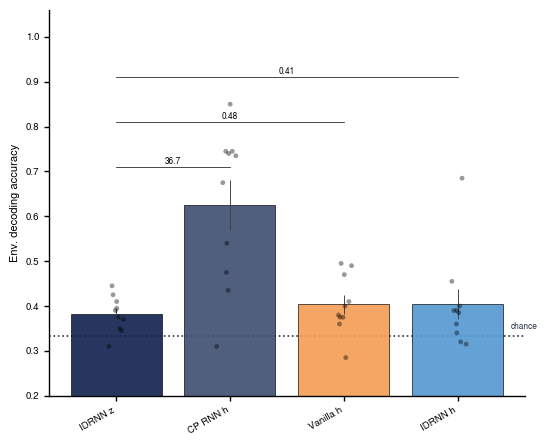

In [6]:
# --- Load panel-d data ---
env = pd.read_csv("env_decoding_canonical.csv")
env = env[env["split"]=="train_data"]
MODELS = [("IDRNN z",  "IDRNN_mu",            COL_IDRNN),
          ("CP RNN h", "common_process_h",    COL_RNN_CP),
          ("Vanilla h","vanilla_h",           COL_VANILLA),
          ("IDRNN h",  "informed_decoder_h",  COL_IDRNN_H)]
env_piv = env.pivot_table(index="dataset_id", columns="model", values="acc_mean")

# --- Plot (bars + grey error bars + jittered dots, mirroring panel a/b) ---
fig, ax = plt.subplots(figsize=(5.5, 4.5))
keys  = [k for _,k,_ in MODELS]
cols  = [c for _,_,c in MODELS]
means = [float(np.nanmean(env_piv[k].values)) for k in keys]
sems  = [float(stats.sem(env_piv[k].dropna().values)) for k in keys]
xs    = np.arange(len(MODELS))
ax.bar(xs, means, color=cols, alpha=0.92, edgecolor="black",
       linewidth=0.5, zorder=2)
ax.errorbar(xs, means, yerr=sems, fmt="none", ecolor="#444444",
            elinewidth=0.7, capsize=0, zorder=3)
rng = np.random.default_rng(0)
for i, k in enumerate(keys):
    v = env_piv[k].dropna().values
    ax.scatter(xs[i] + rng.normal(0, 0.05, len(v)), v, s=12,
               c="black", alpha=0.4, zorder=4, edgecolors="none")
ax.axhline(1/3, ls=":", color=COL_TRUE, lw=1.2, zorder=1)
ax.text(len(MODELS)-0.3, 1/3+0.012, "chance", ha="right",
        va="bottom", fontsize=6, color=COL_TRUE)

# Paired BF brackets: IDRNN_mu vs each other feature
a = env_piv["IDRNN_mu"].values
ymax  = max(means) + max(sems)
h_step = 0.10
for i, k in enumerate(keys[1:]):
    b = env_piv[k].values
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3 or bayesfactor_ttest is None:
        bf = float("nan")
    else:
        t = stats.ttest_rel(a[m], b[m]).statistic
        bf = float(bayesfactor_ttest(t=abs(t), nx=int(m.sum()), paired=True))
    bracket(ax, 0, i+1, ymax + i*h_step, h_step*0.3, fmt_bf(bf))

ax.set_xticks(xs); ax.set_xticklabels([m[0] for m in MODELS], rotation=30, ha="right")
ax.set_ylabel("Env. decoding accuracy")
ax.set_ylim(0.20, ymax + (len(keys)-1)*h_step + 0.08)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
#ax.set_title("d (with IDRNN h)", loc="left", fontweight="bold")
plt.tight_layout()
plt.savefig("final_plots/synth_env_decoding.png", dpi=600, bbox_inches="tight")
plt.show()

## Panel d — environment-structure decoding (without IDRNN h)

Same data, but drops the IDRNN h feature. Comparison narrows to IDRNN z vs the two RNN-h baselines (CP RNN h, Vanilla h).

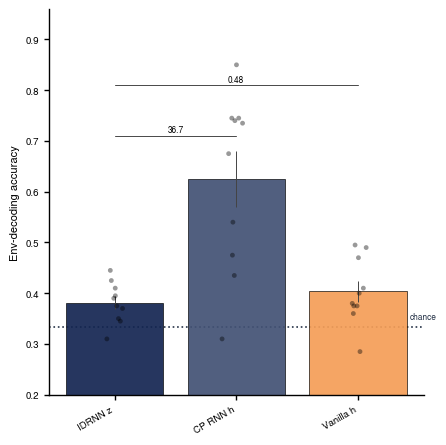

In [7]:
# --- Load panel-d data (no IDRNN h) ---
env = pd.read_csv("env_decoding_canonical.csv")
env = env[env["split"]=="train_data"]
MODELS = [("IDRNN z",  "IDRNN_mu",         COL_IDRNN),
          ("CP RNN h", "common_process_h", COL_RNN_CP),
          ("Vanilla h","vanilla_h",        COL_VANILLA)]
env_piv = env.pivot_table(index="dataset_id", columns="model", values="acc_mean")

# --- Plot (bars + grey error bars + jittered dots, mirroring panel a/b) ---
fig, ax = plt.subplots(figsize=(4.5, 4.5))
keys  = [k for _,k,_ in MODELS]
cols  = [c for _,_,c in MODELS]
means = [float(np.nanmean(env_piv[k].values)) for k in keys]
sems  = [float(stats.sem(env_piv[k].dropna().values)) for k in keys]
xs    = np.arange(len(MODELS))
ax.bar(xs, means, color=cols, alpha=0.92, edgecolor="black",
       linewidth=0.5, zorder=2)
ax.errorbar(xs, means, yerr=sems, fmt="none", ecolor="#444444",
            elinewidth=0.7, capsize=0, zorder=3)
rng = np.random.default_rng(0)
for i, k in enumerate(keys):
    v = env_piv[k].dropna().values
    ax.scatter(xs[i] + rng.normal(0, 0.05, len(v)), v, s=12,
               c="black", alpha=0.4, zorder=4, edgecolors="none")
ax.axhline(1/3, ls=":", color=COL_TRUE, lw=1.2, zorder=1)
ax.text(len(MODELS)-0.35, 1/3+0.012, "chance", ha="right",
        va="bottom", fontsize=6, color=COL_TRUE)

# Paired BF brackets: IDRNN_mu vs each other feature
a = env_piv["IDRNN_mu"].values
ymax  = max(means) + max(sems)
h_step = 0.10
for i, k in enumerate(keys[1:]):
    b = env_piv[k].values
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3 or bayesfactor_ttest is None:
        bf = float("nan")
    else:
        t = stats.ttest_rel(a[m], b[m]).statistic
        bf = float(bayesfactor_ttest(t=abs(t), nx=int(m.sum()), paired=True))
    bracket(ax, 0, i+1, ymax + i*h_step, h_step*0.3, fmt_bf(bf))

ax.set_xticks(xs); ax.set_xticklabels([m[0] for m in MODELS], rotation=30, ha="right")
ax.set_ylabel("Env-decoding accuracy")
ax.set_ylim(0.20, ymax + (len(keys)-1)*h_step + 0.08)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
#ax.set_title("d (without IDRNN h)", loc="left", fontweight="bold")
plt.tight_layout()
plt.savefig("final_plots/synthetic_env_decoding_acc.png", dpi=600, bbox_inches="tight")
plt.show()

## Panel e — marginalisation-ladder simulation (→ α)

IDRNN rollouts under the canonical step-1 z, scored by mean per-trial regret, correlated with true α. Four rungs of the ladder (see `simulation_analysis.pdf`):

- **Observed** (R1) — observed mean regret, no model.
- **No Marg.** (R0) — a single rollout (K=1) on the subject's **exact** reward tape.
- **Noise Marg.** (R2) — exact tape, averaged over K=100 action-noise rollouts (marginalises policy noise ω only).
- **Env.+Noise Marg.** (R3) — averaged over action noise **and** M=100 fresh environments drawn from the generative distribution p(E).

Bars = Pearson r vs true α; error bars = ±SD of the subject-bootstrap Pearson r (B=2000, subjects resampled with replacement), matching the bootstrapping in dezfouli_publication_panels.ipynb / thalmann_results.ipynb; per-bar BF₁₀ vs r=0. Directional prediction: higher α ⇒ lower regret ⇒ negative r. Data source: `plots_dataset0/step1_three_regressions.npz`.

In [ ]:
# --- Load panel-e data ---
tr = np.load("plots_dataset0/step1_three_regressions.npz")
y_tr = tr["true_alpha"]
# (xtick label, npz key, color, bar alpha)
# Marginalisation ladder (see simulation_analysis.pdf):
#   R1 → Observed          (observed mean regret, no model)
#   R0 → No Marg.          (single rollout on the subject's exact env, K=1)
#   R2 → Noise Marg.       (exact env, avg over K action-noise rollouts)
#   R3 → Env.+Noise Marg.  (avg over action noise AND fresh envs from p(E))
PANEL_E_BARS = [
    ("Observed",         "R1_raw_mean_reward", COL_TRUE,  1.00),
    ("No Marg.",         "R0_idrnn",           COL_IDRNN, 0.35),
    ("Noise Marg.",      "R2_idrnn",           COL_IDRNN, 0.65),
    ("Env.+Noise Marg.", "R3_idrnn",           COL_IDRNN, 1.00),
]

# Bootstrapping logic mirrors dezfouli_publication_panels / thalmann_results:
# resample subjects with replacement (B=2000), recompute the Pearson r each
# time, and summarise the bootstrap-r distribution by its SD (the error bar).
# No percentile CIs and no bootstrap point cloud.
rng = np.random.default_rng(1)
panel_e_stats = []
for lab, pkey, col, alpha in PANEL_E_BARS:
    x = np.asarray(tr.get(pkey, np.full_like(y_tr, np.nan)))
    m = np.isfinite(x) & np.isfinite(y_tr)
    if m.sum() < 4:
        panel_e_stats.append(dict(label=lab, color=col, alpha=alpha, r=np.nan,
                                  sd=np.nan, bf=np.nan))
        continue
    xv, yv = x[m], y_tr[m]; n = len(xv)
    r0 = float(pearsonr(xv, yv)[0])
    boots = np.empty(2000)
    for i in range(len(boots)):
        idx = rng.integers(0, n, size=n)
        boots[i] = np.corrcoef(xv[idx], yv[idx])[0, 1]
    bf = float(bayesfactor_pearson(r0, m.sum())) if bayesfactor_pearson else np.nan
    panel_e_stats.append(dict(label=lab, color=col, alpha=alpha, r=r0,
                              sd=float(np.std(boots)), bf=bf))

# --- Plot (bars + grey ±SD error bars; no point cloud) ---
fig, ax = plt.subplots(figsize=(4.5, 4.5))
xs = np.arange(len(panel_e_stats))
heights = [r["r"] for r in panel_e_stats]
sd_err  = [r["sd"] if np.isfinite(r["sd"]) else 0 for r in panel_e_stats]   # ±SD of the bootstrap-r distribution
for xi, h, r in zip(xs, heights, panel_e_stats):
    ax.bar(xi, h, color=r["color"], alpha=r["alpha"],
           edgecolor="black", linewidth=0.5, zorder=2)
ax.errorbar(xs, heights, yerr=sd_err,
            fmt="none", ecolor="#444444", elinewidth=0.7, capsize=0, zorder=3)

# Per-bar BF₁₀ (r vs 0), placed just above the zero line
finite = [(h, s) for h, s in zip(heights, sd_err) if np.isfinite(h)]
y_top = (max([h + s for h, s in finite] + [0.0]) if finite else 0.0) + 0.06
for xi, r in zip(xs, panel_e_stats):
    if np.isfinite(r.get("bf", np.nan)):
        ax.text(xi, y_top, fmt_bf(r["bf"]), ha="center",
                fontsize=plt.rcParams['xtick.labelsize'], color="#333333")

ax.set_xticks(xs)
ax.set_xticklabels([r["label"] for r in panel_e_stats], rotation=25, ha="right")
ax.axhline(0, color="grey", lw=0.5, zorder=1)
ax.set_ylabel("Pearson r  (regret vs α)")
ax.set_ylim((min([h - s for h, s in finite]) - 0.05) if finite else -1.0, y_top + 0.10)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
#ax.set_title("e", loc="left", fontweight="bold")
plt.tight_layout()
plt.savefig("final_plots/snythetic_generative_sim.png", dpi=600, bbox_inches="tight")
plt.show()

## Why `step1_specificity` is a good seed-selection metric

The canonical IDRNN seed (stage_g) is picked by **`step1_specificity` = mismatched-NLL − matched-NLL**. Higher specificity means each lookup z_i decodes its own subject's behaviour markedly better than someone else's z would — i.e. the encoder learned subject-individuating representations rather than a degenerate shared z.

If specificity is a good seed-selection metric we expect: **higher specificity ⇒ better held-out α-decoding** (because subject-individuating z is exactly what α-decoding needs).

This cell walks all 30 nested-CV seeds across all 3 folds and all 10 synthetic datasets (900 seeds total), reads each seed's `step1_specificity` from `runs_dataset{D}_<tag>/fold{F}/seed_{S}/config.json`, loads its held-out IDRNN latents, and runs the same LOO ridge against ground-truth α used in panel b. The scatter is pooled across datasets/folds; Spearman ρ across all 900 seeds is reported.

In [ ]:
# --- Walk every seed: (step1_specificity, LOO α-decoding R²) ---
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

# Per-dataset run-suffix: 5 datasets were retrained with the spec-selection
# tag, the rest with the plain z1 tag.  step1_specificity is saved in config.json
# regardless of which metric drove HP selection, so both are valid here.
DATASET_TAGS = {0:"nested_cv_z1_spec",  1:"nested_cv_z1",
                2:"nested_cv_z1_spec",  3:"nested_cv_z1",
                5:"nested_cv_z1_spec",  7:"nested_cv_z1",
                10:"nested_cv_z1_spec", 12:"nested_cv_z1",
                15:"nested_cv_z1",      17:"nested_cv_z1_spec"}
N_FOLDS = 3

def _loo_r2(Z_train, Z_test, y_test):
    """LOO ridge with train-set PCA, mirroring _loo_ridge in
    analyze_synthetic_nested_cv.py.  Returns R² (sklearn r2_score)."""
    scaler = StandardScaler().fit(Z_train)
    n_pc = min(1, Z_train.shape[1])  # z_dim=1 → PCA is a no-op
    pca = PCA(n_components=n_pc).fit(scaler.transform(Z_train))
    Zp_te = pca.transform(scaler.transform(Z_test))
    preds = np.zeros(len(y_test))
    for tr, te in LeaveOneOut().split(Zp_te):
        mu_z, sd_z = Zp_te[tr].mean(0), Zp_te[tr].std(0) + 1e-8
        mu_y, sd_y = y_test[tr].mean(), y_test[tr].std() + 1e-8
        clf = RidgeCV(alphas=[0.1, 1, 10, 100, 1000])
        clf.fit((Zp_te[tr] - mu_z) / sd_z, (y_test[tr] - mu_y) / sd_y)
        preds[te] = clf.predict((Zp_te[te] - mu_z) / sd_z) * sd_y + mu_y
    return float(r2_score(y_test, preds))

rows = []
for D, tag in DATASET_TAGS.items():
    for F in range(N_FOLDS):
        ap = f"data_dataset{D}/fold{F}/true_param_test.csv"
        if not os.path.exists(ap): continue
        alpha = pd.read_csv(ap)["alphaP_list"].to_numpy()
        runs_root = f"runs_dataset{D}_{tag}/fold{F}"
        data_root = f"data_dataset{D}/fold{F}"
        if not os.path.isdir(runs_root): continue
        for sd_dir in sorted(os.listdir(runs_root)):
            if not sd_dir.startswith("seed_"): continue
            S = int(sd_dir.split("_")[1])
            cfg_p   = f"{runs_root}/{sd_dir}/config.json"
            ltest_p = f"{data_root}/{sd_dir}/{tag}/latents_tensorlatentmodel.pt"
            ltrn_p  = f"{data_root}/{sd_dir}/{tag}/latents_tensorlatentmodel_traindata.pt"
            if not (os.path.exists(cfg_p) and os.path.exists(ltest_p) and os.path.exists(ltrn_p)):
                continue
            spec = json.load(open(cfg_p)).get("step1_specificity")
            if spec is None: continue
            try:
                Z_te = torch.load(ltest_p, map_location="cpu").detach().numpy()
                Z_tr = torch.load(ltrn_p,  map_location="cpu").detach().numpy()
            except Exception:
                continue
            # latents are (n_subj, T, z_dim) — collapse time to a per-subject vec
            if Z_te.ndim == 3: Z_te = Z_te.mean(axis=1)
            if Z_tr.ndim == 3: Z_tr = Z_tr.mean(axis=1)
            try:
                r2 = _loo_r2(Z_tr, Z_te, alpha)
            except Exception:
                r2 = np.nan
            rows.append(dict(dataset=D, fold=F, seed=S, specificity=float(spec), r2=r2))

spec_df = pd.DataFrame(rows)
print(f"seeds collected: {len(spec_df)}  (across {spec_df['dataset'].nunique()} datasets × {N_FOLDS} folds)")

# --- Plot: scatter of (specificity, LOO α-R²) ---
fig, ax = plt.subplots(figsize=(5.5, 4.5))
DS_COLORS = plt.get_cmap("tab10")
for i, D in enumerate(sorted(spec_df["dataset"].unique())):
    sub = spec_df[spec_df["dataset"] == D]
    ax.scatter(sub["specificity"], sub["r2"],
               s=14, color=DS_COLORS(i % 10), alpha=0.5,
               edgecolors="none", zorder=2, label=f"ds{D}")

# Highlight the canonical seed (top-1 by spec) per (dataset, fold)
top1 = spec_df.sort_values("specificity").groupby(["dataset", "fold"]).tail(1)
ax.scatter(top1["specificity"], top1["r2"],
           s=30, facecolors="none", edgecolors="black",
           linewidth=0.9, zorder=4, label="top-1 by spec (canonical)")

# Spearman + linear trend
m = np.isfinite(spec_df["specificity"]) & np.isfinite(spec_df["r2"])
rho, p_rho = spearmanr(spec_df.loc[m, "specificity"], spec_df.loc[m, "r2"])
xfit = np.linspace(spec_df.loc[m, "specificity"].min(),
                   spec_df.loc[m, "specificity"].max(), 50)
b, a = np.polyfit(spec_df.loc[m, "specificity"], spec_df.loc[m, "r2"], 1)
ax.plot(xfit, b*xfit + a, lw=1.2, color="#444444", zorder=3,
        label=f"linear fit (slope={b:+.2f})")
ax.text(0.04, 0.96, f"Spearman ρ = {rho:+.3f}\np = {p_rho:.1e}\nN = {m.sum()}",
        transform=ax.transAxes, va="top", fontsize=plt.rcParams['xtick.labelsize'])

ax.axhline(0, color="grey", lw=0.5, zorder=1)
ax.set_xlabel("step1 specificity  (mismatched − matched NLL)")
ax.set_ylabel("held-out α-decoding R²  (LOO ridge)")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(loc="lower right", ncol=2, fontsize=6, handletextpad=0.4,
          columnspacing=0.8, frameon=False)
plt.tight_layout(); plt.show()

### Diagnostic 1 — per-dataset Spearman ρ (spec vs held-out α-R²)

Pooling all 10 datasets gave ρ ≈ -0.035 (null). But each dataset has its own R² ceiling driven by intrinsic signal-to-noise, so pooling can blur a within-dataset trend. This cell computes Spearman ρ separately for each dataset (90 seeds each = 30 seeds × 3 folds) and shows them as a forest plot. If most dots sit clearly to the right of 0, specificity is a useful *within-dataset* selector even if the pooled cloud looks flat. If they cluster around 0, the null is robust.

In [9]:
# --- Diagnostic 1: per-dataset Spearman ρ (spec vs held-out α-R²) ---
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

DATASET_TAGS = {0:"nested_cv_z1_spec",  1:"nested_cv_z1",
                2:"nested_cv_z1_spec",  3:"nested_cv_z1",
                5:"nested_cv_z1_spec",  7:"nested_cv_z1",
                10:"nested_cv_z1_spec", 12:"nested_cv_z1",
                15:"nested_cv_z1",      17:"nested_cv_z1_spec"}
N_FOLDS = 3

def _loo_r2(Z_train, Z_test, y_test):
    scaler = StandardScaler().fit(Z_train)
    n_pc = min(1, Z_train.shape[1])
    pca = PCA(n_components=n_pc).fit(scaler.transform(Z_train))
    Zp_te = pca.transform(scaler.transform(Z_test))
    preds = np.zeros(len(y_test))
    for tr, te in LeaveOneOut().split(Zp_te):
        mu_z, sd_z = Zp_te[tr].mean(0), Zp_te[tr].std(0) + 1e-8
        mu_y, sd_y = y_test[tr].mean(), y_test[tr].std() + 1e-8
        clf = RidgeCV(alphas=[0.1, 1, 10, 100, 1000])
        clf.fit((Zp_te[tr] - mu_z) / sd_z, (y_test[tr] - mu_y) / sd_y)
        preds[te] = clf.predict((Zp_te[te] - mu_z) / sd_z) * sd_y + mu_y
    return float(r2_score(y_test, preds))

rows = []
for D, tag in DATASET_TAGS.items():
    for F in range(N_FOLDS):
        ap = f"data_dataset{D}/fold{F}/true_param_test.csv"
        if not os.path.exists(ap): continue
        alpha = pd.read_csv(ap)["alphaP_list"].to_numpy()
        runs_root = f"runs_dataset{D}_{tag}/fold{F}"
        data_root = f"data_dataset{D}/fold{F}"
        if not os.path.isdir(runs_root): continue
        for sd_dir in sorted(os.listdir(runs_root)):
            if not sd_dir.startswith("seed_"): continue
            cfg_p   = f"{runs_root}/{sd_dir}/config.json"
            ltest_p = f"{data_root}/{sd_dir}/{tag}/latents_tensorlatentmodel.pt"
            ltrn_p  = f"{data_root}/{sd_dir}/{tag}/latents_tensorlatentmodel_traindata.pt"
            if not (os.path.exists(cfg_p) and os.path.exists(ltest_p) and os.path.exists(ltrn_p)):
                continue
            spec = json.load(open(cfg_p)).get("step1_specificity")
            if spec is None: continue
            try:
                Z_te = torch.load(ltest_p, map_location="cpu").detach().numpy()
                Z_tr = torch.load(ltrn_p,  map_location="cpu").detach().numpy()
            except Exception: continue
            if Z_te.ndim == 3: Z_te = Z_te.mean(axis=1)
            if Z_tr.ndim == 3: Z_tr = Z_tr.mean(axis=1)
            try:    r2 = _loo_r2(Z_tr, Z_te, alpha)
            except Exception: r2 = np.nan
            rows.append(dict(dataset=D, fold=F, specificity=float(spec), r2=r2))
spec_df = pd.DataFrame(rows)

# Per-dataset Spearman ρ with bootstrap 95% CI
def boot_rho_ci(x, y, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    x = np.asarray(x); y = np.asarray(y)
    n = len(x); boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        boots[i] = spearmanr(x[idx], y[idx]).correlation
    return float(np.nanpercentile(boots, 2.5)), float(np.nanpercentile(boots, 97.5))

per_ds = []
for D in sorted(spec_df["dataset"].unique()):
    sub = spec_df[spec_df["dataset"] == D].dropna(subset=["specificity", "r2"])
    if len(sub) < 5:
        per_ds.append(dict(dataset=D, rho=np.nan, p=np.nan, lo=np.nan, hi=np.nan, n=len(sub)))
        continue
    rho_d, p_d = spearmanr(sub["specificity"], sub["r2"])
    lo, hi = boot_rho_ci(sub["specificity"].values, sub["r2"].values)
    per_ds.append(dict(dataset=D, rho=float(rho_d), p=float(p_d), lo=lo, hi=hi, n=len(sub)))
per_ds = pd.DataFrame(per_ds)

# Pooled ρ for reference
m = np.isfinite(spec_df["specificity"]) & np.isfinite(spec_df["r2"])
pooled_rho, pooled_p = spearmanr(spec_df.loc[m, "specificity"], spec_df.loc[m, "r2"])

# --- Forest plot ---
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ys = np.arange(len(per_ds))
for i, row in per_ds.iterrows():
    col = COL_IDRNN if row["p"] < 0.05 and row["rho"] > 0 else (
          COL_VANILLA if row["p"] < 0.05 and row["rho"] < 0 else "#888888")
    ax.errorbar(row["rho"], i, xerr=[[row["rho"]-row["lo"]], [row["hi"]-row["rho"]]],
                fmt="o", color=col, ecolor=col, elinewidth=0.7,
                markersize=5, capsize=0, zorder=3)
ax.axvline(0, color="grey", lw=0.5, zorder=1)
ax.axvline(pooled_rho, color="black", ls="--", lw=0.8, zorder=2,
           label=f"pooled ρ = {pooled_rho:+.3f}")
ax.set_yticks(ys); ax.set_yticklabels([f"ds{int(r['dataset'])}  (N={int(r['n'])})" for _, r in per_ds.iterrows()])
ax.set_xlabel("Spearman ρ  (step1 specificity vs held-out α-R²)")
ax.set_xlim(-1, 1)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(loc="lower right", fontsize=6, frameon=False)
plt.tight_layout(); plt.show()

print(per_ds.to_string(index=False))

KeyboardInterrupt: 

### Diagnostic 2 — does specificity predict held-out *predictive* fit?

The first plot asked whether spec predicts a **representational** quality metric (α-decoding R²). Here we ask whether spec predicts a **predictive** quality metric: held-out per-trial NLL on the test subjects, read from `rnn_resultslatentmodel.csv` (column `normalized_likelihood`, which despite the name is per-trial NLL — see [analyze_synthetic_nested_cv.py:182](analyze_synthetic_nested_cv.py#L182)).

Specificity and NLL could decouple. Specificity is a *training* metric tied to whether each lookup z carries subject-specific info; NLL is held-out behavioural fit. If spec predicts NLL even though it doesn't predict α-R², it's still useful — it'd pick seeds that *generalise predictively*, just not the ones whose latents happen to align with α. If both are null, the case for using spec for seed selection is fully dead and we should fall back to held-out NLL.

seeds collected: 900


/tmp/ipykernel_1384373/4275807449.py:67: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Nimbus Sans.
  plt.tight_layout(); plt.show()
/ictstr01/home/hcai/marvin.mathony/tools/apps/mamba/envs/RNNproject/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Nimbus Sans.
  fig.canvas.print_figure(bytes_io, **kw)


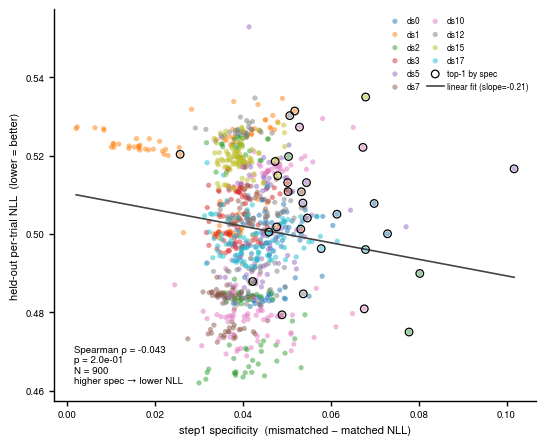


per-dataset ρ (spec vs held-out NLL):
  ds 0: ρ=+0.286  p=6.22e-03  N=90
  ds 1: ρ=+0.134  p=2.07e-01  N=90
  ds 2: ρ=-0.117  p=2.73e-01  N=90
  ds 3: ρ=+0.272  p=9.45e-03  N=90
  ds 5: ρ=+0.368  p=3.55e-04  N=90
  ds 7: ρ=+0.420  p=3.74e-05  N=90
  ds10: ρ=+0.379  p=2.34e-04  N=90
  ds12: ρ=-0.107  p=3.17e-01  N=90
  ds15: ρ=+0.128  p=2.29e-01  N=90
  ds17: ρ=-0.082  p=4.44e-01  N=90


In [6]:
# --- Diagnostic 2: spec vs held-out per-trial NLL (predictive fit) ---
from scipy.stats import spearmanr

DATASET_TAGS = {0:"nested_cv_z1_spec",  1:"nested_cv_z1",
                2:"nested_cv_z1_spec",  3:"nested_cv_z1",
                5:"nested_cv_z1_spec",  7:"nested_cv_z1",
                10:"nested_cv_z1_spec", 12:"nested_cv_z1",
                15:"nested_cv_z1",      17:"nested_cv_z1_spec"}
N_FOLDS = 3

rows = []
for D, tag in DATASET_TAGS.items():
    for F in range(N_FOLDS):
        runs_root = f"runs_dataset{D}_{tag}/fold{F}"
        data_root = f"data_dataset{D}/fold{F}"
        if not os.path.isdir(runs_root): continue
        for sd_dir in sorted(os.listdir(runs_root)):
            if not sd_dir.startswith("seed_"): continue
            cfg_p = f"{runs_root}/{sd_dir}/config.json"
            nll_p = f"{data_root}/{sd_dir}/{tag}/rnn_resultslatentmodel.csv"
            if not (os.path.exists(cfg_p) and os.path.exists(nll_p)): continue
            spec = json.load(open(cfg_p)).get("step1_specificity")
            if spec is None: continue
            try:
                nll_df_seed = pd.read_csv(nll_p)
            except Exception: continue
            if "normalized_likelihood" not in nll_df_seed.columns: continue
            # per-seed mean held-out per-trial NLL (averaged across test sessions)
            nll_mean = float(nll_df_seed["normalized_likelihood"].astype(float).mean())
            rows.append(dict(dataset=D, fold=F, specificity=float(spec), nll=nll_mean))
nll_seed_df = pd.DataFrame(rows)
print(f"seeds collected: {len(nll_seed_df)}")

# --- Plot: scatter of (specificity, held-out NLL) ---
fig, ax = plt.subplots(figsize=(5.5, 4.5))
DS_COLORS = plt.get_cmap("tab10")
for i, D in enumerate(sorted(nll_seed_df["dataset"].unique())):
    sub = nll_seed_df[nll_seed_df["dataset"] == D]
    ax.scatter(sub["specificity"], sub["nll"],
               s=14, color=DS_COLORS(i % 10), alpha=0.5,
               edgecolors="none", zorder=2, label=f"ds{D}")

# Top-1-by-spec per (dataset, fold) — what stage_g picks
top1 = nll_seed_df.sort_values("specificity").groupby(["dataset", "fold"]).tail(1)
ax.scatter(top1["specificity"], top1["nll"],
           s=30, facecolors="none", edgecolors="black",
           linewidth=0.9, zorder=4, label="top-1 by spec")

m = np.isfinite(nll_seed_df["specificity"]) & np.isfinite(nll_seed_df["nll"])
rho, p_rho = spearmanr(nll_seed_df.loc[m, "specificity"], nll_seed_df.loc[m, "nll"])
xfit = np.linspace(nll_seed_df.loc[m, "specificity"].min(),
                   nll_seed_df.loc[m, "specificity"].max(), 50)
b, a = np.polyfit(nll_seed_df.loc[m, "specificity"], nll_seed_df.loc[m, "nll"], 1)
ax.plot(xfit, b*xfit + a, lw=1.2, color="#444444", zorder=3,
        label=f"linear fit (slope={b:+.2f})")
# NB: lower NLL = better, so a NEGATIVE Spearman ρ means spec helps.
direction = "higher spec → lower NLL ✓" if rho < 0 else "higher spec → higher NLL ✗"
ax.text(0.04, 0.04,
        f"Spearman ρ = {rho:+.3f}\np = {p_rho:.1e}\nN = {m.sum()}\n{direction}",
        transform=ax.transAxes, va="bottom", fontsize=plt.rcParams['xtick.labelsize'])

ax.set_xlabel("step1 specificity  (mismatched − matched NLL)")
ax.set_ylabel("held-out per-trial NLL  (lower = better)")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(loc="upper right", ncol=2, fontsize=6, handletextpad=0.4,
          columnspacing=0.8, frameon=False)
plt.tight_layout(); plt.show()

# Per-dataset Spearman summary
print("\nper-dataset ρ (spec vs held-out NLL):")
for D in sorted(nll_seed_df["dataset"].unique()):
    sub = nll_seed_df[nll_seed_df["dataset"] == D]
    r_d, p_d = spearmanr(sub["specificity"], sub["nll"])
    print(f"  ds{D:>2d}: ρ={r_d:+.3f}  p={p_d:.2e}  N={len(sub)}")

## Poster panel — five published panels combined (uniform fonts)

Combines the five synthetic-poster plots into one figure:
**a** held-out NLL · **b** α-decoding R² (LOO) · **c** α vs IDRNN z · **d** env-structure decoding · **e** marginalisation ladder.

All five are redrawn as **native subplots in one figure** so the font family and every font size are identical across panels — compositing the saved PNGs would not be, since each was saved at its own figsize. Typography is bumped to poster sizes via a local `rc_context` (the per-panel cells above are unaffected). Depends only on the **Setup** cell + light data files; it does **not** run the heavy seed-walking diagnostic cells. Saves `final_plots/synthetic_poster_panel.png` (300 dpi) and `.pdf`.

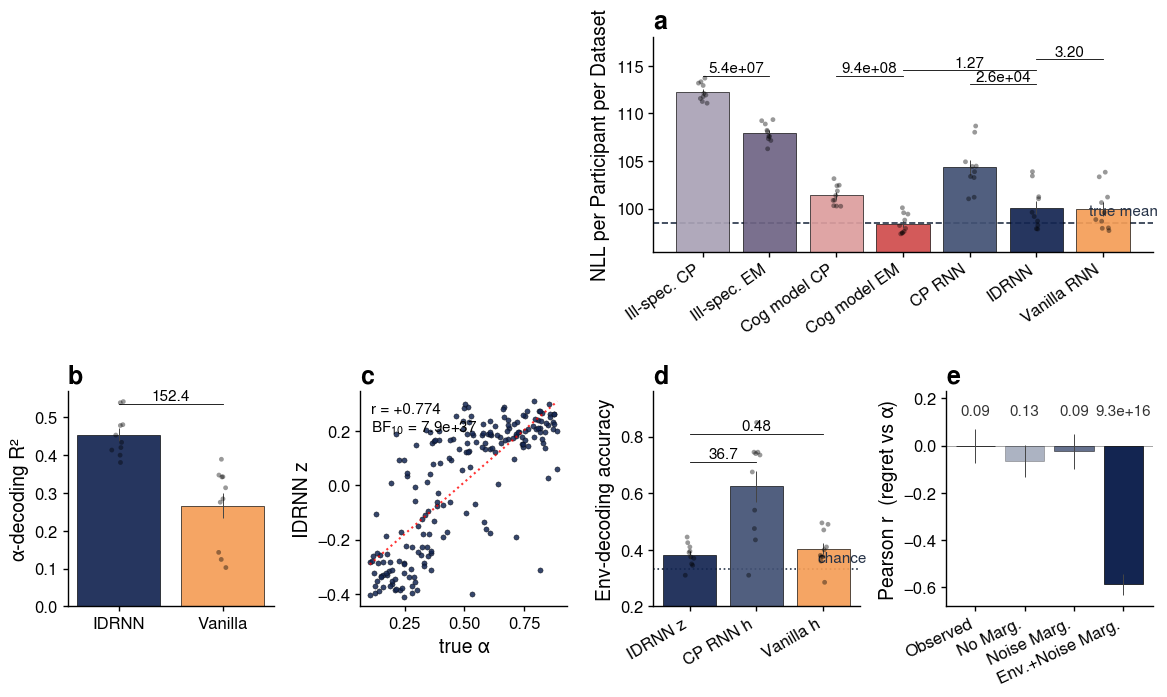

Saved final_plots/synthetic_poster_panel.png / .pdf / .svg


In [4]:
# === Poster panel: a (held-out NLL) · b (alpha-decode R2) · c (z vs alpha) ·
#     d (env-structure decoding) · e (marginalisation ladder) ===
# Regenerates all five published synthetic panels as NATIVE subplots in ONE figure, so
# the font family and every font size are identical across panels. (Compositing the saved
# PNGs would not be uniform: each was saved at its own figsize, so the same 8 pt label
# renders at a different physical size per panel.) Colours come from the COL_* variables in
# the Setup cell, so editing the palette there updates this panel too. Uses only the Setup
# cell + light data files (CSV/JSON/npy/npz); it never runs the heavy seed-walking cells.
import matplotlib.gridspec as gridspec

# --- Uniform poster typography, applied to the whole figure via rc_context ---
FS_BASE, FS_LABEL, FS_TICK, FS_ANNOT, FS_LETTER = 13, 14, 12, 11, 18
POSTER_RC = {
    "font.size":       FS_BASE,
    "axes.titlesize":  FS_BASE,
    "axes.labelsize":  FS_LABEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_ANNOT,
    "mathtext.default": "regular",   # render $BF_{10}$ subscript in the sans font
}

def _bracket(ax, x1, x2, y, h, txt, fs=FS_ANNOT):
    ax.plot([x1, x2], [y + h, y + h], lw=0.6, c="black")
    ax.text((x1 + x2) / 2, y + h * 1.1, txt, ha="center", va="bottom", fontsize=fs)

with plt.rc_context(POSTER_RC):
    fig = plt.figure(figsize=(14, 7.4))
    gs = gridspec.GridSpec(2, 4, figure=fig, height_ratios=[1.0, 1.0],
                           hspace=0.65, wspace=0.42)
    ax_a = fig.add_subplot(gs[0, 2:])
    ax_b = fig.add_subplot(gs[1, 0])
    ax_c = fig.add_subplot(gs[1, 1])
    ax_d = fig.add_subplot(gs[1, 2])
    ax_e = fig.add_subplot(gs[1, 3])

    # ============================================================= Panel a: held-out NLL
    cog_keys = [("Q_CP", "Q (common fit)"), ("Q_EM", "Q (MAP)"),
                ("FQ_CP", "FQ (common fit)"), ("FQ_EM", "FQ (MAP)"),
                ("True", "True model")]
    nll_df = {k: [] for k in ["Q_CP", "Q_EM", "FQ_CP", "FQ_EM",
                              "RNN_CP", "IDRNN", "Vanilla", "True"]}
    cp_df = pd.read_csv("cp_rnn_nll_nestedcv.csv") if os.path.exists("cp_rnn_nll_nestedcv.csv") else None
    # Cognitive-model NLLs from the per-fold refit (compute_synthetic_cog_nll_perfold.py):
    # fit on each nested-CV fold's train subjects, evaluated on the SAME held-out fold
    # subjects as the RNN bars (legacy model_eval_dfvanilla.csv used the separate test
    # simulation — a different population draw; kept only as fallback).
    cog_pf = (pd.read_csv("cog_nll_perfold_synthetic.csv")
              if os.path.exists("cog_nll_perfold_synthetic.csv") else None)
    if cog_pf is None:
        print("WARNING NLL panel: cog_nll_perfold_synthetic.csv missing -> "
              "legacy test-sim cog NLLs (NOT the same eval subjects as the RNNs)")
    for D in DATASETS:
        pf = cog_pf[cog_pf["dataset_id"] == D] if cog_pf is not None else None
        if pf is not None and len(pf):
            for tag, name in cog_keys:
                v = pf[pf["model"] == name]["nll_summed"].values
                nll_df[tag].append(float(np.mean(v)) if len(v) else np.nan)
        else:
            if cog_pf is not None:
                print(f"WARNING NLL panel: dataset {D} missing from per-fold CSV -> legacy fallback")
            ev = pd.read_csv(f"data_dataset{D}/model_eval_dfvanilla.csv")
            for tag, name in cog_keys:
                v = ev[ev["model"] == name]["normalized_likelihood"].values
                nll_df[tag].append(float(np.mean(v)) if len(v) else np.nan)
        rec = json.load(open(f"{Z1_BASE}/dataset{D}/nested_cv_summary.json"))
        s = rec["summary"]
        nll_df["IDRNN"].append(s["nll_idrnn_mean"] * T_TRIALS)
        nll_df["Vanilla"].append(s["nll_vanilla_mean"] * T_TRIALS)
        nll_df["RNN_CP"].append(float(cp_df[cp_df["dataset_id"] == D]["nll_summed"].mean())
                                if cp_df is not None else np.nan)
    nll_df = pd.DataFrame(nll_df)
    bf_Q           = paired_bf(nll_df["Q_CP"],  nll_df["Q_EM"])
    bf_FQ          = paired_bf(nll_df["FQ_CP"], nll_df["FQ_EM"])
    bf_RNNCP_IDRNN = paired_bf(nll_df["RNN_CP"], nll_df["IDRNN"])
    bf_Van_IDRNN   = paired_bf(nll_df["Vanilla"], nll_df["IDRNN"])
    bf_IDRNN_FQ_EM = paired_bf(nll_df["FQ_EM"], nll_df["IDRNN"])

    labels = ["Ill-spec. CP", "Ill-spec. EM", "Cog model CP", "Cog model EM",
              "CP RNN", "IDRNN", "Vanilla RNN"]
    keys   = ["Q_CP", "Q_EM", "FQ_CP", "FQ_EM", "RNN_CP", "IDRNN", "Vanilla"]
    cols   = [COL_Q_CP, COL_Q_EM, COL_FQ_CP, COL_FQ_EM, COL_RNN_CP, COL_IDRNN, COL_VANILLA]
    means  = [nll_df[k].mean() for k in keys]
    sems   = [stats.sem(nll_df[k].dropna()) for k in keys]
    xs     = np.arange(len(labels))
    ax_a.bar(xs, means, color=cols, alpha=0.92, edgecolor="black", linewidth=0.5, zorder=2)
    ax_a.errorbar(xs, means, yerr=sems, fmt="none", ecolor="#444444",
                  elinewidth=0.7, capsize=0, zorder=3)
    rng = np.random.default_rng(0)
    for i, k in enumerate(keys):
        v = nll_df[k].dropna().values
        if len(v) == 0:
            continue
        ax_a.scatter(xs[i] + rng.normal(0, 0.05, len(v)), v, s=12,
                     c="black", alpha=0.4, zorder=4, edgecolors="none")
    true_mean = nll_df["True"].mean()
    ax_a.axhline(true_mean, ls="--", color=COL_TRUE, lw=1.2, zorder=1)
    ymax = max(means) + max(sems); h_step = 0.05 * (max(means) - true_mean)
    yb = ymax + h_step
    _bracket(ax_a, 0, 1, yb,                h_step * 0.3, fmt_bf(bf_Q))
    _bracket(ax_a, 2, 3, yb,                h_step * 0.3, fmt_bf(bf_FQ))
    _bracket(ax_a, 4, 5, yb - h_step * 1.3, h_step * 0.3, fmt_bf(bf_RNNCP_IDRNN))
    _bracket(ax_a, 5, 6, yb + h_step * 2.5, h_step * 0.3, fmt_bf(bf_Van_IDRNN))
    _bracket(ax_a, 3, 5, yb + 0.85 * h_step, h_step * 0.3, fmt_bf(bf_IDRNN_FQ_EM))
    ax_a.set_xticks(xs); ax_a.set_xticklabels(labels, rotation=35, ha="right")
    ax_a.set_ylabel("NLL per Participant per Dataset")
    ax_a.set_ylim(bottom=true_mean - 3, top=ymax + 5)
    ax_a.text(1.01, true_mean + 0.5, "true mean", color=COL_TRUE, va="bottom", ha="right",
              transform=ax_a.get_yaxis_transform(), fontsize=FS_ANNOT)

    # ====================================================== Panel b: alpha-decoding R2 (LOO)
    r2_idr, r2_van = [], []
    for D in DATASETS:
        rec = json.load(open(f"{Z1_BASE}/dataset{D}/nested_cv_summary.json"))
        r2_idr.append(fold_mean(rec, "idrnn",   "decode_r2_mean_across_seeds"))
        r2_van.append(fold_mean(rec, "vanilla", "decode_r2_mean_across_seeds"))
    r2_idr = np.array(r2_idr); r2_van = np.array(r2_van)
    bf_r2 = paired_bf(r2_idr, r2_van)
    xs = [0, 1]; means = [np.nanmean(r2_idr), np.nanmean(r2_van)]
    sems = [stats.sem(r2_idr[np.isfinite(r2_idr)]), stats.sem(r2_van[np.isfinite(r2_van)])]
    ax_b.bar(xs, means, color=[COL_IDRNN, COL_VANILLA], edgecolor="black",
             linewidth=0.5, alpha=0.92, zorder=2)
    ax_b.errorbar(xs, means, yerr=sems, fmt="none", ecolor="#444444",
                  elinewidth=0.7, capsize=0, zorder=3)
    rng = np.random.default_rng(1)
    for i, d in enumerate([r2_idr, r2_van]):
        ax_b.scatter(xs[i] + rng.normal(0, 0.05, len(d)), d, s=12,
                     c="black", alpha=0.4, edgecolors="none", zorder=4)
    ax_b.set_xticks(xs); ax_b.set_xticklabels(["IDRNN", "Vanilla"])
    ax_b.set_ylabel("α-decoding R²"); ax_b.axhline(0, color="grey", lw=0.5)
    ymax = max(means) + max(sems)
    _bracket(ax_b, 0, 1, ymax * 1.05, ymax * 0.05, fmt_bf(bf_r2))

    # ===================================================== Panel c: alpha vs IDRNN z (ds0)
    z0 = np.load(f"{CANON_DS0}/latents_train.npy").reshape(-1)
    alpha0 = pd.read_csv("data_dataset0/true_parameter_values.csv")["alphaP_list"].values[:len(z0)]
    r_c = float(np.corrcoef(alpha0, z0)[0, 1])
    bf_c = float(bayesfactor_pearson(r_c, len(z0))) if bayesfactor_pearson else float("nan")
    if r_c < 0:
        z0 = -z0; r_c = -r_c
    slope, intercept = np.polyfit(alpha0, z0, 1)
    x_line = np.linspace(alpha0.min(), alpha0.max(), 200)
    ax_c.scatter(alpha0, z0, s=14, color=COL_IDRNN, edgecolor="black",
                 linewidth=0.3, alpha=0.85)
    ax_c.plot(x_line, slope * x_line + intercept, "r:", lw=1.5, alpha=0.8)
    ax_c.set_xlabel("true α"); ax_c.set_ylabel("IDRNN z")
    ax_c.text(0.05, 0.95, f"r = {r_c:+.3f}\n$BF_{{10}}$ = {fmt_bf(bf_c)}",
              transform=ax_c.transAxes, va="top", fontsize=FS_ANNOT)

    # ================================================= Panel d: env-structure decoding (no IDRNN h)
    env = pd.read_csv("env_decoding_canonical.csv")
    env = env[env["split"] == "train_data"]
    MODELS = [("IDRNN z",   "IDRNN_mu",         COL_IDRNN),
              ("CP RNN h",  "common_process_h", COL_RNN_CP),
              ("Vanilla h", "vanilla_h",        COL_VANILLA)]
    env_piv = env.pivot_table(index="dataset_id", columns="model", values="acc_mean")
    keys  = [k for _, k, _ in MODELS]
    cols  = [c for _, _, c in MODELS]
    means = [float(np.nanmean(env_piv[k].values)) for k in keys]
    sems  = [float(stats.sem(env_piv[k].dropna().values)) for k in keys]
    xs    = np.arange(len(MODELS))
    ax_d.bar(xs, means, color=cols, alpha=0.92, edgecolor="black", linewidth=0.5, zorder=2)
    ax_d.errorbar(xs, means, yerr=sems, fmt="none", ecolor="#444444",
                  elinewidth=0.7, capsize=0, zorder=3)
    rng = np.random.default_rng(0)
    for i, k in enumerate(keys):
        v = env_piv[k].dropna().values
        ax_d.scatter(xs[i] + rng.normal(0, 0.05, len(v)), v, s=12,
                     c="black", alpha=0.4, zorder=4, edgecolors="none")
    ax_d.axhline(1 / 3, ls=":", color=COL_TRUE, lw=1.2, zorder=1)
    ax_d.text(len(MODELS) - 0.35, 1 / 3 + 0.012, "chance", ha="right",
              va="bottom", fontsize=FS_ANNOT, color=COL_TRUE)
    a = env_piv["IDRNN_mu"].values
    ymax = max(means) + max(sems); h_step = 0.10
    for i, k in enumerate(keys[1:]):
        b = env_piv[k].values
        m = np.isfinite(a) & np.isfinite(b)
        if m.sum() < 3 or bayesfactor_ttest is None:
            bf = float("nan")
        else:
            t = stats.ttest_rel(a[m], b[m]).statistic
            bf = float(bayesfactor_ttest(t=abs(t), nx=int(m.sum()), paired=True))
        _bracket(ax_d, 0, i + 1, ymax + i * h_step, h_step * 0.3, fmt_bf(bf))
    ax_d.set_xticks(xs); ax_d.set_xticklabels([m[0] for m in MODELS], rotation=30, ha="right")
    ax_d.set_ylabel("Env-decoding accuracy")
    ax_d.set_ylim(0.20, ymax + (len(keys) - 1) * h_step + 0.08)

    # ================================================= Panel e: marginalisation ladder -> alpha
    # Bootstrapping matches dezfouli_publication_panels / thalmann_results: resample
    # subjects with replacement (B=2000), recompute Pearson r, and use ±SD of the
    # bootstrap-r distribution as the error bar (no percentile CI, no point cloud).
    tr = np.load("plots_dataset0/step1_three_regressions.npz")
    y_tr = tr["true_alpha"]
    PANEL_E_BARS = [
        ("Observed",         "R1_raw_mean_reward", COL_TRUE,  1.00),
        ("No Marg.",         "R0_idrnn",           COL_IDRNN, 0.35),
        ("Noise Marg.",      "R2_idrnn",           COL_IDRNN, 0.65),
        ("Env.+Noise Marg.", "R3_idrnn",           COL_IDRNN, 1.00),
    ]
    rng = np.random.default_rng(1)
    panel_e_stats = []
    for lab, pkey, col, alpha in PANEL_E_BARS:
        x = np.asarray(tr.get(pkey, np.full_like(y_tr, np.nan)))
        m = np.isfinite(x) & np.isfinite(y_tr)
        if m.sum() < 4:
            panel_e_stats.append(dict(label=lab, color=col, alpha=alpha, r=np.nan,
                                      sd=np.nan, bf=np.nan))
            continue
        xv, yv = x[m], y_tr[m]; n = len(xv)
        r0 = float(pearsonr(xv, yv)[0])
        boots = np.empty(2000)
        for i in range(len(boots)):
            idx = rng.integers(0, n, size=n)
            boots[i] = np.corrcoef(xv[idx], yv[idx])[0, 1]
        bf = float(bayesfactor_pearson(r0, m.sum())) if bayesfactor_pearson else np.nan
        panel_e_stats.append(dict(label=lab, color=col, alpha=alpha, r=r0,
                                  sd=float(np.std(boots)), bf=bf))
    xs = np.arange(len(panel_e_stats))
    heights = [r["r"] for r in panel_e_stats]
    sd_err  = [r["sd"] if np.isfinite(r["sd"]) else 0 for r in panel_e_stats]   # ±SD of the bootstrap-r distribution
    for xi, h, r in zip(xs, heights, panel_e_stats):
        ax_e.bar(xi, h, color=r["color"], alpha=r["alpha"],
                 edgecolor="black", linewidth=0.5, zorder=2)
    ax_e.errorbar(xs, heights, yerr=sd_err,
                  fmt="none", ecolor="#444444", elinewidth=0.7, capsize=0, zorder=3)
    finite = [(h, s) for h, s in zip(heights, sd_err) if np.isfinite(h)]
    y_top = (max([h + s for h, s in finite] + [0.0]) if finite else 0.0) + 0.06
    for xi, r in zip(xs, panel_e_stats):
        if np.isfinite(r.get("bf", np.nan)):
            ax_e.text(xi, y_top, fmt_bf(r["bf"]), ha="center", fontsize=FS_ANNOT, color="#333333")
    ax_e.set_xticks(xs)
    ax_e.set_xticklabels([r["label"] for r in panel_e_stats], rotation=25, ha="right")
    ax_e.axhline(0, color="grey", lw=0.5, zorder=1)
    ax_e.set_ylabel("Pearson r  (regret vs α)")
    ax_e.set_ylim((min([h - s for h, s in finite]) - 0.05) if finite else -1.0, y_top + 0.10)

    # --- Panel letters (uniform, bold) ---
    for ax, lett in [(ax_a, "a"), (ax_b, "b"), (ax_c, "c"), (ax_d, "d"), (ax_e, "e")]:
        ax.set_title(lett, loc="left", fontweight="bold", fontsize=FS_LETTER)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.savefig("final_plots/synthetic_poster_panel.png", dpi=300, bbox_inches="tight")
    fig.savefig("final_plots/synthetic_poster_panel.pdf", bbox_inches="tight")
    fig.savefig("final_plots/synthetic_poster_panel.svg", bbox_inches="tight")
    plt.show()
print("Saved final_plots/synthetic_poster_panel.png / .pdf / .svg")

In [ ]:
# === Publication panel: a (held-out NLL) · b (alpha-decode R2) · c (z vs alpha) ·
#     d (env-structure decoding) · e (marginalisation ladder) ===
# Regenerates all five published synthetic panels as NATIVE subplots in ONE figure, so
# the font family and every font size are identical across panels. (Compositing the saved
# PNGs would not be uniform: each was saved at its own figsize, so the same 8 pt label
# renders at a different physical size per panel.) Colours come from the COL_* variables in
# the Setup cell, so editing the palette there updates this panel too. Uses only the Setup
# cell + light data files (CSV/JSON/npy/npz); it never runs the heavy seed-walking cells.
# NHB Guidelines
# All panels are NATIVE subplots in ONE figure at W_FULL (180 mm) with uniform journal typography
# (5–7 pt). Saved WITHOUT bbox_inches="tight" so figsize stays authoritative under the globally
# enabled constrained_layout. Reads only light data files (CSV/NPZ/NPY); never runs seed-walking cells.
import matplotlib.gridspec as gridspec

MM = 1 / 25.4
W_FULL = 180 * MM     # NHB double-column hard max

FS_BASE, FS_LABEL, FS_TICK, FS_ANNOT, FS_LETTER = 6, 6, 6, 5, 8
FS_BFNUM = 5          # dense per-bar BF labels (trait axis, 14 bars)
JOURNAL_RC = {
    "font.size": FS_BASE, "axes.titlesize": FS_BASE, "axes.labelsize": FS_LABEL,
    "xtick.labelsize": FS_TICK, "ytick.labelsize": FS_TICK, "legend.fontsize": FS_ANNOT,
    "mathtext.default": "regular",
}

def _bracket(ax, x1, x2, y, h, txt, fs=FS_ANNOT):
    ax.plot([x1, x2], [y + h, y + h], lw=0.6, c="black")
    ax.text((x1 + x2) / 2, y + h * 1.1, txt, ha="center", va="bottom", fontsize=fs)

with plt.rc_context(JOURNAL_RC):
    fig = plt.figure(figsize=(W_FULL, 4.9), layout="constrained")
    fig.get_layout_engine().set(h_pad=0.02, hspace=0.0)   # h_pad is in inches; hspace is a fraction
    outer = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.0])

    gs0 = outer[0].subgridspec(1, 100, wspace=0.0)
    ax_a = fig.add_subplot(gs0[0, 0:55])        # a — held-out NLL
    ax_b = fig.add_subplot(gs0[0, 64:100])      

    gs1 = outer[1].subgridspec(1, 100, wspace=0.0)
    ax_c = fig.add_subplot(gs1[0, 0:30])   
    ax_d = fig.add_subplot(gs1[0, 33:63]) 
    ax_e = fig.add_subplot(gs1[0, 66:99])

    # ============================================================= Panel a: held-out NLL
    cog_keys = [("Q_CP", "Q (common fit)"), ("Q_EM", "Q (MAP)"),
                ("FQ_CP", "FQ (common fit)"), ("FQ_EM", "FQ (MAP)"),
                ("True", "True model")]
    nll_df = {k: [] for k in ["Q_CP", "Q_EM", "FQ_CP", "FQ_EM",
                              "RNN_CP", "IDRNN", "Vanilla", "True"]}
    cp_df = pd.read_csv("cp_rnn_nll_nestedcv.csv") if os.path.exists("cp_rnn_nll_nestedcv.csv") else None
    # Cognitive-model NLLs from the per-fold refit (compute_synthetic_cog_nll_perfold.py):
    # fit on each nested-CV fold's train subjects, evaluated on the SAME held-out fold
    # subjects as the RNN bars.  The legacy model_eval_dfvanilla.csv evaluated the cog
    # models on the separate test simulation (a different population draw) — kept only
    # as a fallback while the per-fold CSV is being computed.
    cog_pf = (pd.read_csv("cog_nll_perfold_synthetic.csv")
              if os.path.exists("cog_nll_perfold_synthetic.csv") else None)
    if cog_pf is None:
        print("WARNING panel a: cog_nll_perfold_synthetic.csv missing -> "
              "legacy test-sim cog NLLs (NOT the same eval subjects as the RNNs)")
    for D in DATASETS:
        pf = cog_pf[cog_pf["dataset_id"] == D] if cog_pf is not None else None
        if pf is not None and len(pf):
            for tag, name in cog_keys:
                v = pf[pf["model"] == name]["nll_summed"].values
                nll_df[tag].append(float(np.mean(v)) if len(v) else np.nan)
        else:
            if cog_pf is not None:
                print(f"WARNING panel a: dataset {D} missing from per-fold CSV -> legacy fallback")
            ev = pd.read_csv(f"data_dataset{D}/model_eval_dfvanilla.csv")
            for tag, name in cog_keys:
                v = ev[ev["model"] == name]["normalized_likelihood"].values
                nll_df[tag].append(float(np.mean(v)) if len(v) else np.nan)
        rec = json.load(open(f"{Z1_BASE}/dataset{D}/nested_cv_summary.json"))
        s = rec["summary"]
        nll_df["IDRNN"].append(s["nll_idrnn_mean"] * T_TRIALS)
        nll_df["Vanilla"].append(s["nll_vanilla_mean"] * T_TRIALS)
        nll_df["RNN_CP"].append(float(cp_df[cp_df["dataset_id"] == D]["nll_summed"].mean())
                                if cp_df is not None else np.nan)
    nll_df = pd.DataFrame(nll_df)
    bf_Q           = paired_bf(nll_df["Q_CP"],  nll_df["Q_EM"])
    bf_FQ          = paired_bf(nll_df["FQ_CP"], nll_df["FQ_EM"])
    bf_RNNCP_IDRNN = paired_bf(nll_df["RNN_CP"], nll_df["IDRNN"])
    bf_Van_IDRNN   = paired_bf(nll_df["Vanilla"], nll_df["IDRNN"])
    bf_IDRNN_FQ_EM = paired_bf(nll_df["FQ_EM"], nll_df["IDRNN"])

    labels = ["Ill-spec. CP", "Ill-spec. EM", "Cog model CP", "Cog model EM",
              "CP RNN", "IDRNN", "Vanilla RNN"]
    keys   = ["Q_CP", "Q_EM", "FQ_CP", "FQ_EM", "RNN_CP", "IDRNN", "Vanilla"]
    cols   = [COL_Q_CP, COL_Q_EM, COL_FQ_CP, COL_FQ_EM, COL_RNN_CP, COL_IDRNN, COL_VANILLA]
    means  = [nll_df[k].mean() for k in keys]
    sems   = [stats.sem(nll_df[k].dropna()) for k in keys]
    xs     = np.arange(len(labels))
    ax_a.bar(xs, means, color=cols, alpha=0.92, edgecolor="black", linewidth=0.5, zorder=2)
    ax_a.errorbar(xs, means, yerr=sems, fmt="none", ecolor="#444444",
                  elinewidth=0.7, capsize=0, zorder=3)
    rng = np.random.default_rng(0)
    for i, k in enumerate(keys):
        v = nll_df[k].dropna().values
        if len(v) == 0:
            continue
        ax_a.scatter(xs[i] + rng.normal(0, 0.05, len(v)), v, s=12,
                     c="black", alpha=0.4, zorder=4, edgecolors="none")
    true_mean = nll_df["True"].mean()
    ax_a.axhline(true_mean, ls="--", color=COL_TRUE, lw=1.2, zorder=1)
    ymax = max(means) + max(sems); h_step = 0.05 * (max(means) - true_mean)
    yb = ymax + h_step
    _bracket(ax_a, 0, 1, yb,                h_step * 0.3, fmt_bf(bf_Q))
    _bracket(ax_a, 2, 3, yb,                h_step * 0.3, fmt_bf(bf_FQ))
    _bracket(ax_a, 4, 5, yb - h_step * 1.3, h_step * 0.3, fmt_bf(bf_RNNCP_IDRNN))
    _bracket(ax_a, 5, 6, yb + h_step * 2.5, h_step * 0.3, fmt_bf(bf_Van_IDRNN))
    _bracket(ax_a, 3, 5, yb + 0.85 * h_step, h_step * 0.3, fmt_bf(bf_IDRNN_FQ_EM))
    ax_a.set_xticks(xs); ax_a.set_xticklabels(labels, rotation=35, ha="right")
    ax_a.set_ylabel("NLL per Participant per Dataset")
    ax_a.set_ylim(bottom=true_mean - 3, top=ymax + 5)
    ax_a.text(1.18, true_mean + 0.5, "true mean", color=COL_TRUE, va="bottom", ha="right",
              transform=ax_a.get_yaxis_transform(), fontsize=FS_ANNOT)

    # ====================================================== Panel b: alpha-decoding R2 (LOO)
    r2_idr, r2_van = [], []
    for D in DATASETS:
        rec = json.load(open(f"{Z1_BASE}/dataset{D}/nested_cv_summary.json"))
        r2_idr.append(fold_mean(rec, "idrnn",   "decode_r2_mean_across_seeds"))
        r2_van.append(fold_mean(rec, "vanilla", "decode_r2_mean_across_seeds"))
    r2_idr = np.array(r2_idr); r2_van = np.array(r2_van)
    bf_r2 = paired_bf(r2_idr, r2_van)
    xs = [0, 1]; means = [np.nanmean(r2_idr), np.nanmean(r2_van)]
    sems = [stats.sem(r2_idr[np.isfinite(r2_idr)]), stats.sem(r2_van[np.isfinite(r2_van)])]
    ax_b.bar(xs, means, color=[COL_IDRNN, COL_VANILLA], edgecolor="black",
             linewidth=0.5, alpha=0.92, zorder=2)
    ax_b.errorbar(xs, means, yerr=sems, fmt="none", ecolor="#444444",
                  elinewidth=0.7, capsize=0, zorder=3)
    rng = np.random.default_rng(1)
    for i, d in enumerate([r2_idr, r2_van]):
        ax_b.scatter(xs[i] + rng.normal(0, 0.05, len(d)), d, s=12,
                     c="black", alpha=0.4, edgecolors="none", zorder=4)
    ax_b.set_xticks(xs); ax_b.set_xticklabels(["IDRNN", "Vanilla"])
    ax_b.set_ylabel("α-decoding R²"); ax_b.axhline(0, color="grey", lw=0.5)
    ymax = max(means) + max(sems)
    _bracket(ax_b, 0, 1, ymax * 1.05, ymax * 0.05, fmt_bf(bf_r2))

    # ===================================================== Panel c: alpha vs IDRNN z (ds0)
    z0 = np.load(f"{CANON_DS0}/latents_train.npy").reshape(-1)
    alpha0 = pd.read_csv("data_dataset0/true_parameter_values.csv")["alphaP_list"].values[:len(z0)]
    r_c = float(np.corrcoef(alpha0, z0)[0, 1])
    bf_c = float(bayesfactor_pearson(r_c, len(z0))) if bayesfactor_pearson else float("nan")
    if r_c < 0:
        z0 = -z0; r_c = -r_c
    slope, intercept = np.polyfit(alpha0, z0, 1)
    x_line = np.linspace(alpha0.min(), alpha0.max(), 200)
    ax_c.scatter(alpha0, z0, s=14, color=COL_IDRNN, edgecolor="black",
                 linewidth=0.3, alpha=0.85)
    ax_c.plot(x_line, slope * x_line + intercept, "r:", lw=1.5, alpha=0.8)
    ax_c.set_xlabel("true α"); ax_c.set_ylabel("IDRNN z")
    ax_c.text(0.05, 0.95, f"r = {r_c:+.3f}\n$BF_{{10}}$ = {fmt_bf(bf_c)}",
              transform=ax_c.transAxes, va="top", fontsize=FS_ANNOT)

    # ================================================= Panel d: env-structure decoding (no IDRNN h)
    env = pd.read_csv("env_decoding_canonical.csv")
    env = env[env["split"] == "train_data"]
    MODELS = [("IDRNN z",   "IDRNN_mu",         COL_IDRNN),
              ("CP RNN h",  "common_process_h", COL_RNN_CP),
              ("Vanilla h", "vanilla_h",        COL_VANILLA)]
    env_piv = env.pivot_table(index="dataset_id", columns="model", values="acc_mean")
    keys  = [k for _, k, _ in MODELS]
    cols  = [c for _, _, c in MODELS]
    means = [float(np.nanmean(env_piv[k].values)) for k in keys]
    sems  = [float(stats.sem(env_piv[k].dropna().values)) for k in keys]
    xs    = np.arange(len(MODELS))
    ax_d.bar(xs, means, color=cols, alpha=0.92, edgecolor="black", linewidth=0.5, zorder=2)
    ax_d.errorbar(xs, means, yerr=sems, fmt="none", ecolor="#444444",
                  elinewidth=0.7, capsize=0, zorder=3)
    rng = np.random.default_rng(0)
    for i, k in enumerate(keys):
        v = env_piv[k].dropna().values
        ax_d.scatter(xs[i] + rng.normal(0, 0.05, len(v)), v, s=12,
                     c="black", alpha=0.4, zorder=4, edgecolors="none")
    ax_d.axhline(1 / 3, ls=":", color=COL_TRUE, lw=1.2, zorder=1)
    ax_d.text(len(MODELS) - 0.05, 1 / 3 + 0.012, "chance", ha="right",
              va="bottom", fontsize=FS_ANNOT, color=COL_TRUE)
    a = env_piv["IDRNN_mu"].values
    ymax = max(means) + max(sems); h_step = 0.10
    for i, k in enumerate(keys[1:]):
        b = env_piv[k].values
        m = np.isfinite(a) & np.isfinite(b)
        if m.sum() < 3 or bayesfactor_ttest is None:
            bf = float("nan")
        else:
            t = stats.ttest_rel(a[m], b[m]).statistic
            bf = float(bayesfactor_ttest(t=abs(t), nx=int(m.sum()), paired=True))
        _bracket(ax_d, 0, i + 1, ymax + i * h_step, h_step * 0.3, fmt_bf(bf))
    ax_d.set_xticks(xs); ax_d.set_xticklabels([m[0] for m in MODELS], rotation=30, ha="right")
    ax_d.set_ylabel("Env-decoding accuracy")
    ax_d.set_ylim(0.20, ymax + (len(keys) - 1) * h_step + 0.08)

    # ================================================= Panel e: marginalisation ladder -> alpha
    # Bootstrapping matches dezfouli_publication_panels / thalmann_results: resample
    # subjects with replacement (B=2000), recompute Pearson r, and use ±SD of the
    # bootstrap-r distribution as the error bar (no percentile CI, no point cloud).
    tr = np.load("plots_dataset0/step1_three_regressions.npz")
    y_tr = tr["true_alpha"]
    PANEL_E_BARS = [
        ("Observed",         "R1_raw_mean_reward", COL_TRUE,  1.00),
        ("No Marg.",         "R0_idrnn",           COL_IDRNN, 0.35),
        ("Noise Marg.",      "R2_idrnn",           COL_IDRNN, 0.65),
        ("Env.+Noise Marg.", "R3_idrnn",           COL_IDRNN, 1.00),
    ]
    rng = np.random.default_rng(1)
    panel_e_stats = []
    for lab, pkey, col, alpha in PANEL_E_BARS:
        x = np.asarray(tr.get(pkey, np.full_like(y_tr, np.nan)))
        m = np.isfinite(x) & np.isfinite(y_tr)
        if m.sum() < 4:
            panel_e_stats.append(dict(label=lab, color=col, alpha=alpha, r=np.nan,
                                      sd=np.nan, bf=np.nan))
            continue
        xv, yv = x[m], y_tr[m]; n = len(xv)
        r0 = float(pearsonr(xv, yv)[0])
        boots = np.empty(2000)
        for i in range(len(boots)):
            idx = rng.integers(0, n, size=n)
            boots[i] = np.corrcoef(xv[idx], yv[idx])[0, 1]
        bf = float(bayesfactor_pearson(r0, m.sum())) if bayesfactor_pearson else np.nan
        panel_e_stats.append(dict(label=lab, color=col, alpha=alpha, r=r0,
                                  sd=float(np.std(boots)), bf=bf))
    xs = np.arange(len(panel_e_stats))
    heights = [r["r"] for r in panel_e_stats]
    sd_err  = [r["sd"] if np.isfinite(r["sd"]) else 0 for r in panel_e_stats]   # ±SD of the bootstrap-r distribution
    for xi, h, r in zip(xs, heights, panel_e_stats):
        ax_e.bar(xi, h, color=r["color"], alpha=r["alpha"],
                 edgecolor="black", linewidth=0.5, zorder=2)
    ax_e.errorbar(xs, heights, yerr=sd_err,
                  fmt="none", ecolor="#444444", elinewidth=0.7, capsize=0, zorder=3)
    finite = [(h, s) for h, s in zip(heights, sd_err) if np.isfinite(h)]
    y_top = (max([h + s for h, s in finite] + [0.0]) if finite else 0.0) + 0.06
    for xi, r in zip(xs, panel_e_stats):
        if np.isfinite(r.get("bf", np.nan)):
            ax_e.text(xi, y_top, fmt_bf(r["bf"]), ha="center", fontsize=FS_ANNOT, color="#333333")
    ax_e.set_xticks(xs)
    ax_e.set_xticklabels([r["label"] for r in panel_e_stats], rotation=25, ha="right")
    ax_e.axhline(0, color="grey", lw=0.5, zorder=1)
    ax_e.set_ylabel("Pearson r  (regret vs α)")
    ax_e.set_ylim((min([h - s for h, s in finite]) - 0.05) if finite else -1.0, y_top + 0.10)

    # --- Panel letters (uniform, bold) ---
    for ax, lett in [(ax_a, "a"), (ax_b, "b"), (ax_c, "c"), (ax_d, "d"), (ax_e, "e")]:
        ax.set_title(lett, loc="left", fontweight="bold", fontsize=FS_LETTER)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.savefig("final_plots/synthetic_poster_panel.png", dpi=600)  # NO bbox_inches="tight" — figsize (180 mm) stays authoritative
    fig.savefig("final_plots/synthetic_poster_panel.pdf")
    fig.savefig("final_plots/synthetic_poster_panel.svg")
    plt.show()
print("Saved final_plots/synthetic_poster_panel.png / .pdf / .svg")

AttributeError: 'NoneType' object has no attribute 'set'

<Figure size 708.661x490 with 0 Axes>